# LangChain ile bir RAG Uygulaması

LLM'lerin sağladığı en güçlü uygulamalardan biri, gelişmiş soru-cevap (Q&A) sohbet robotlarıdır. Bunlar, belirli kaynak bilgileriyle ilgili soruları yanıtlayabilen uygulamalardır. Bu uygulamalar, Retrieval Augmented Generation (RAG) olarak bilinen bir teknik kullanır. Bu eğitimde, yapılandırılmamış bir metin veri kaynağı üzerinde basit bir Q&A uygulamasının nasıl oluşturulacağı gösterilecektir.

# RAG (RETRIEVAL AUGMENTED GENERATION) NEDİR ?

2020 yılında bu terimi ortaya atan makalenin baş yazarı Patrick Lewis, yüzlerce makale ve düzinelerce ticari hizmette giderek büyüyen bir yöntem ailesini tanımlayan ve üretken yapay zekanın geleceğini temsil ettiğine inandığı bu hoş olmayan kısaltma için özür diledi.

**Makale** -->  https://arxiv.org/pdf/2005.11401

***Retrieval augmented generation (RAG)*** , doğal dil işleme (NLP) alanında, üretilen metnin kalitesini artırmak için arama tabanlı ve üretim tabanlı modellerin güçlü yönlerini birleştiren yenilikçi bir yaklaşımdır.

| Harf                           | Aşama                                           |  |
| ------------------------------ | ----------------------------------------------- | -------- |
| **R – Retrieve (Getir)**       | Yararlı bilgileri bul.                          |          |
| **A – Augment (Zenginleştir)** | Bulunan bilgileri yapay zekanın bilgisine ekle. |          |
| **G – Generate (Üret)**        | Daha iyi bir yanıt oluştur.                     |          |


Tekniğin kökleri en azından 1970'lerin başına kadar uzanıyor. O dönemde, bilgi arama araştırmacıları, başlangıçta beyzbol gibi dar konularda metne erişmek için doğal dil işleme ( NLP ) kullanan uygulamalar olan soru-cevap sistemleri adını verdikleri prototipleri geliştirdiler.

1990'ların ortalarında, Ask Jeeves hizmeti (şimdiki adıyla Ask.com), şık giyimli bir vale maskotuyla soru cevaplamayı popüler hale getirdi. IBM'in Watson'ı, 2011 yılında Jeopardy! adlı yarışma programında iki insan şampiyonu rahatlıkla yendiğinde televizyonda ünlü oldu.



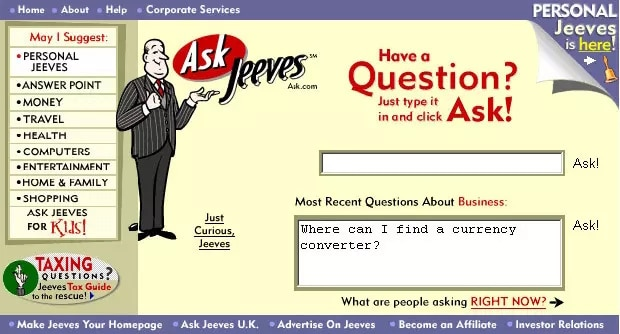

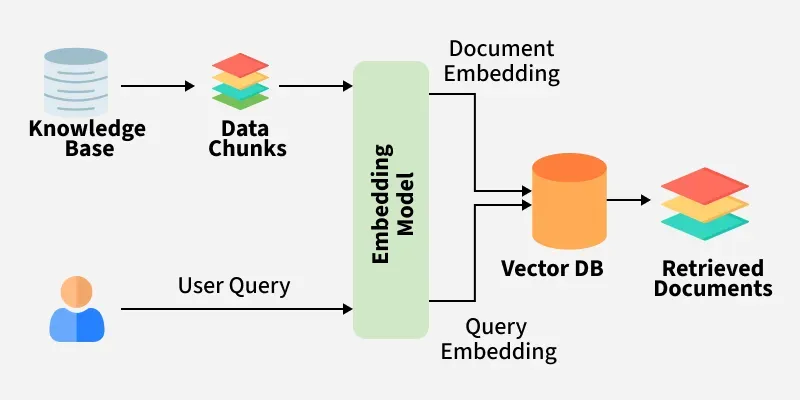

### 1. Knowledge Base (Bilgi Tabanı)
Bu, sistemin elinde bulunan tüm bilgilerin saklandığı ham veri deposudur.
Burada genellikle şu tür veriler bulunur:

- Dokümanlar (PDF, Word, Notlar, Web sayfaları vs.)

- Veri setleri

- Metin tabanlı içerikler (örneğin marka yorumları, teknik dökümanlar, blog yazıları, FAQ listeleri)

Bu aşamada veri henüz “ham” haldedir yani modelin anlayacağı biçimde işlenmemiştir.

### 2. Data Chunks (Veri Parçacıkları)

RAG sistemleri uzun metinlerle çalışmakta zorlandığı için, bilgi tabanı küçük parçalara (chunk) bölünür.
Her “chunk”, birkaç cümle ya da paragraf uzunluğunda olur.
Bunun amacı:

- Modelin dikkatini küçük, anlamlı birimlere odaklamak,

- Daha doğru benzerlik araması yapmak,

- Performansı artırmak.

Bu işlem sırasında genellikle “text splitting” stratejileri kullanılır (örneğin LangChain’de RecursiveCharacterTextSplitter).

### 3. Embedding Model (Gömme Modeli)

Bu model, hem bilgi tabanındaki veri parçacıklarını hem de kullanıcı sorgusunu vektör uzayına dönüştürür.

- Her metin parçası (chunk) için bir document embedding (doküman vektörü) oluşturulur.

- Kullanıcının sorduğu soru için bir query embedding (sorgu vektörü) oluşturulur.

Bu embedding’ler sayılardan oluşan yüksek boyutlu temsillerdir (örneğin 768 boyutlu bir vektör).
Amaç: Anlamsal benzerlikleri sayısal olarak ölçebilmek.
Bu aşamada genellikle Sentence Transformers, OpenAI Embeddings (text-embedding-3-large), Instructor XL, ya da E5 gibi modeller kullanılır.

### 4. Vector DB (Vektör Veritabanı)

Oluşturulan tüm doküman embedding’leri bu veritabanında saklanır.
Bu veritabanı, anlamsal arama (semantic search) yapabilecek özel bir yapıya sahiptir.

**Klasik ilişkisel veri tabanlarından farkı:**

- Burada metinler değil, vektörler saklanır.

- Benzerlik sorguları “string eşleşmesiyle” değil, cosine similarity / Euclidean distance gibi matematiksel ölçütlerle yapılır.

**Popüler vektör veritabanları:**

Chroma, FAISS, Pinecone, Weaviate, Milvus, Qdrant

### 5. Query Embedding (Sorgu Gömmesi)

Kullanıcının yazdığı “User Query”, örneğin:

“Chatbot'larda RAG sistemin önemi nedir?”

- Embedding model bu sorguyu da bir vektöre dönüştürür.

- Bu vektör, veri tabanındaki tüm doküman vektörleriyle karşılaştırılır.

Amaç:Kullanıcının sorduğu şeyle en çok benzer anlamı taşıyan doküman parçalarını bulmak.

## RAG hangi sorunları çözer?



1.   Factual Inaccuracies and Hallucinations (Gerçeklere Aykırı Bilgiler ve Halüsinasyonlar)
2.   Outdated Information (Güncel Olmayan Bilgiler)
3. Contextual Relevance (Bağlamsal Alaka)
4. Domain Specific Knowledge (Alana Özgü Bilgi)
5. Cost and Efficiency (Maliyet ve Verimlilik)
6. Scalability Across Domains (Alanlar Arası Ölçeklenebilirlik)




| Framework / Sistem                          | Öne Çıkan Özellikler / Notlar                                                                                                    |
| ------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| **LangChain**                               | En yaygın kullanılan; doküman yükleyiciler, chain mantığı, LLM + retrieval entegrasyonu kolaydır.        |
| **Haystack (deepset)**                      | Production ortamlarında RAG, Q&A sistemleri için oldukça tercih ediliyor.
| **LlamaIndex**                              | Doküman indeksleme + sorgu bağlantısı konusunda esnek bir araç (eski adı GPT-Index)                     |
| **RAGFlow**                                 | Derin belge anlayışı ile modüler RAG sistemleri kurmaya odaklı bir framework                  |
| **Cognita**                                 | Modüler, API tabanlı, üretime yönelik RAG sistemleri için tasarlanmış açık kaynak framework                 |
| **LLMWare**                                 | Başlangıç dostu, RAG uygulamaları için uçtan uca örneklerle başlayan bir framework önerisi olarak öne çıkar |
| **LightRAG**                                | Basit, hızlı RAG sunucusu + Web UI + API desteği sunan bir araç                                                    |
| **RAGchain**                                | PyPI üzerinde “workflow” odaklı bir framework olarak yer alıyor                                                   |
| **FlashRAG (Toolkit / Framework karışımı)** | Hem araştırma hem pratik uygulamalar için modüler yapı, çeşitli yöntemler ve benchmarklar içeriyor.                |




| Kütüphane / Modül | İşlev / Kullanım Alanı                                                                                               |  |
| ----------------- | -------------------------------------------------------------------------------------------------------------------- | ------------------ |
| **FlashRAG**      | Araştırma ve geliştirme amaçlı modüller farklı RAG yöntemleri, benchmark dataset’leri vb. içeriyor   |                    |
| **Rankify**       | Retrieval + re-ranking + RAG birleşik modüler toolkit                                                   |                    |
| **RankLLM**       | LLM’leri re-ranker olarak kullanmak için tasarlanmış bir Python kütüphanesi                             |                    |
| **Unstructured**  | PDF, HTML, Word gibi dokümanları parçalamak / yüklemek için kullanılan popüler bir araç kitaplığıdır  |                    |
| **PageMage**      | Özellikle araştırma makaleleri ve akademik belgeler için yapı / katman bazlı PDF çıkarımı sağlar    |                    |
| **Marker**        | Doküman parçalama, özellikle PDF işlemleri için kullanılan bir başka yardımcı kütüphane             |                    |
| **FAISS**         | Vektör benzerlik araması için güçlü, optimize edilmiş kütüphane (yerel vektör araması)          |                    |
| **Scikit-learn**  | Klasik makine öğrenmesi modelleri, önişleme adımları için hâlâ “yardımcı” olarak kullanılır       |                    |
| **RDFLib**        | Bilgi grafikleri, RDF veri yapılarıyla çalışman gerekiyorsa destek sağlar


---
## 2.  Ortam Kurulumu

Gerekli kütüphaneleri yükleyelim. Bu projede kullanacağımız ana araçlar:

- **LangChain**: RAG pipeline'ı oluşturmak için
- **OpenAI**: Embedding ve LLM için
- **ChromaDB**: Vektör veritabanı olarak


In [ ]:
# Gerekli kütüphaneleri yükleyelim
!pip install -q langchain langchain-openai langchain-community langchain-chroma \
    chromadb openai tiktoken pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.6/330.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.1/500.1 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66

In [ ]:
# API anahtarını ayarlayalım
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

print(" API anahtarı ayarlandı")

 API anahtarı ayarlandı


---
## 3. 📚 Knowledge Base (Bilgi Tabanı) Oluşturma

RAG'ın ilk adımı, LLM'in kullanacağı **bilgi tabanını** hazırlamaktır.
Bu bilgi tabanı PDF, TXT, web sayfası, CSV gibi farklı kaynaklardan oluşabilir.

### Doküman Yükleme Yöntemleri

LangChain birçok farklı kaynak için **Document Loader** sağlar:

| Loader | Kaynak Türü |
|--------|------------|
| `TextLoader` | .txt dosyaları |
| `PyPDFLoader` | .pdf dosyaları |
| `CSVLoader` | .csv dosyaları |
| `WebBaseLoader` | Web sayfaları |
| `DirectoryLoader` | Bir klasördeki tüm dosyalar |

Şimdi örnek bir bilgi tabanı oluşturalım.


In [ ]:
# ============================================================
# Örnek Bilgi Tabanı - Türkçe içeriklerle oluşturalım
# ============================================================

# Örnek metin dosyaları oluşturalım
os.makedirs("knowledge_base", exist_ok=True)

# ----- Doküman 1: Yapay Zeka Temelleri -----
with open("knowledge_base/yapay_zeka.txt", "w", encoding="utf-8") as f:
    f.write("""Yapay Zeka (AI) Nedir?

Yapay zeka, makinelerin insan benzeri zeka göstermesini sağlayan bilgisayar bilimi dalıdır.
Yapay zeka sistemleri öğrenme, problem çözme, karar verme ve dil anlama gibi görevleri
yerine getirebilir.

Yapay zekanın alt dalları şunlardır:

1. Makine Öğrenmesi (Machine Learning): Veriden öğrenen algoritmalar geliştirme yöntemidir.
Makine öğrenmesi, deneyimden otomatik olarak gelişen bilgisayar algoritmalarının çalışılmasıdır.
Üç ana türü vardır: Denetimli Öğrenme, Denetimsiz Öğrenme ve Pekiştirmeli Öğrenme.

2. Derin Öğrenme (Deep Learning): Yapay sinir ağlarını kullanan özel bir makine öğrenmesi
yöntemidir. Çok katmanlı sinir ağları kullanarak karmaşık örüntüleri öğrenebilir.
Görüntü tanıma, ses tanıma ve doğal dil işleme gibi alanlarda büyük başarılar elde etmiştir.

3. Doğal Dil İşleme (NLP): Bilgisayarların insan dilini anlamasını ve üretmesini sağlayan
alandır. Metin sınıflandırma, duygu analizi, makine çevirisi ve chatbot geliştirme gibi
uygulamaları vardır. GPT, BERT gibi büyük dil modelleri NLP alanında çığır açmıştır.

4. Bilgisayarla Görü (Computer Vision): Bilgisayarların görsel verileri anlamasını sağlayan
alandır. Nesne tanıma, yüz tanıma ve otonom araç teknolojileri bu alanın uygulamalarıdır.
""")

# ----- Doküman 2: Transformer Mimarisi -----
with open("knowledge_base/transformer.txt", "w", encoding="utf-8") as f:
    f.write("""Transformer Mimarisi

Transformer, 2017 yılında Google araştırmacıları tarafından "Attention Is All You Need"
makalesiyle tanıtılan devrimsel bir derin öğrenme mimarisidir.

Temel Bileşenleri:

Self-Attention Mekanizması: Transformer'ın en önemli yeniliğidir. Bir cümledeki her kelimenin
diğer tüm kelimelerle ilişkisini hesaplar. Bu sayede uzun mesafeli bağımlılıkları yakalayabilir.
Örneğin 'Kedi minderin üzerinde uyuyordu, o çok yorgundu' cümlesinde 'o' zamirinin 'kedi'ye
atıfta bulunduğunu anlayabilir.

Multi-Head Attention: Birden fazla attention başlığı kullanarak farklı ilişki türlerini
eşzamanlı olarak öğrenir. Her başlık farklı bir temsil alt uzayına odaklanır.

Positional Encoding: Transformer'da RNN'lerin aksine sıralı işleme yoktur. Bu nedenle
kelimelerin konumsal bilgisini eklemek için positional encoding kullanılır.

Feed-Forward Neural Network: Her attention katmanından sonra tam bağlı bir sinir ağı
katmanı gelir. Bu katman doğrusal olmayan dönüşümler uygular.

Encoder-Decoder Yapısı: Orijinal Transformer hem encoder hem decoder içerir.
Encoder girdi dizisini işler, decoder ise çıktı dizisini üretir.
BERT sadece encoder, GPT sadece decoder kullanır.

Transformer tabanlı modeller: GPT serisi (OpenAI), BERT (Google), T5 (Google),
LLaMA (Meta), Claude (Anthropic) gibi modeller Transformer mimarisini temel alır.
""")

# ----- Doküman 3: Prompt Engineering -----
with open("knowledge_base/prompt_engineering.txt", "w", encoding="utf-8") as f:
    f.write("""Prompt Engineering (İstem Mühendisliği)

Prompt engineering, yapay zeka modellerinden istenen çıktıyı almak için girdi metinlerini
(prompt) optimize etme sanatı ve bilimidir.

Temel Prompt Teknikleri:

1. Zero-Shot Prompting: Modele herhangi bir örnek vermeden doğrudan görev tanımı yapılır.
Örnek: 'Bu cümlenin duygusunu analiz et: Bugün hava çok güzel!'

2. Few-Shot Prompting: Modele birkaç örnek vererek istenen çıktı formatını gösterilir.
Bu yöntem modelin görev kalıbını anlamasına yardımcı olur.
Örnek: 'Pozitif: Bugün harika bir gün! / Negatif: Çok kötü hissediyorum. / ?: Film çok sıkıcıydı.'

3. Chain-of-Thought (CoT): Model adım adım düşünmeye yönlendirilir.
Bu teknik özellikle matematik ve mantık problemlerinde başarılıdır.
Örnek: 'Adım adım düşünerek bu problemi çöz...'

4. Role Prompting: Modele belirli bir rol verilir.
Örnek: 'Sen deneyimli bir Python geliştiricisisin. Şu kodu incele...'

5. System Prompting: Modelin genel davranışını belirleyen üst düzey talimatlar verilir.
Yanıt formatı, dil, ton ve kısıtlamalar burada tanımlanır.

İyi Prompt Yazmanın Kuralları:
- Net ve spesifik olun
- Bağlam sağlayın
- Çıktı formatını belirtin
- Karmaşık görevleri adımlara bölün
- Sınırlamaları belirtin
""")

print(" Bilgi tabanı dosyaları oluşturuldu!")
print(f" Dosyalar: {os.listdir('knowledge_base')}")

 Bilgi tabanı dosyaları oluşturuldu!
 Dosyalar: ['transformer.txt', 'prompt_engineering.txt', 'yapay_zeka.txt']


### Dokümanları LangChain ile Yükleyelim

LangChain'in `Document` nesneleri iki ana bileşenden oluşur:
- **`page_content`**: Dokümanın metin içeriği
- **`metadata`**: Doküman hakkında ek bilgiler (kaynak, sayfa no, vs.)


In [ ]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader

# ----- Yöntem 1: Tek Dosya Yükleme -----
single_loader = TextLoader("knowledge_base/yapay_zeka.txt", encoding="utf-8")
single_doc = single_loader.load()

print("=" * 60)
print(" TEK DOSYA YÜKLEME")
print("=" * 60)
print(f"Yüklenen doküman sayısı: {len(single_doc)}")
print(f"Doküman tipi: {type(single_doc[0])}")
print(f"Metadata: {single_doc[0].metadata}")
print(f"İçerik (ilk 200 karakter): {single_doc[0].page_content[:200]}...")

print()

# ----- Yöntem 2: Klasör Yükleme -----
dir_loader = DirectoryLoader(
    "knowledge_base/",         # klasör yolu
    glob="**/*.txt",            # dosya deseni
    loader_cls=TextLoader,      # kullanılacak loader
    loader_kwargs={"encoding": "utf-8"}
)
all_docs = dir_loader.load()

print("=" * 60)
print(" KLASÖR YÜKLEME")
print("=" * 60)
print(f"Toplam doküman sayısı: {len(all_docs)}")
for i, doc in enumerate(all_docs):
    print(f"  Doküman {i+1}: {doc.metadata['source']} "
          f"({len(doc.page_content)} karakter)")

 TEK DOSYA YÜKLEME
Yüklenen doküman sayısı: 1
Doküman tipi: <class 'langchain_core.documents.base.Document'>
Metadata: {'source': 'knowledge_base/yapay_zeka.txt'}
İçerik (ilk 200 karakter): Yapay Zeka (AI) Nedir?

Yapay zeka, makinelerin insan benzeri zeka göstermesini sağlayan bilgisayar bilimi dalıdır.
Yapay zeka sistemleri öğrenme, problem çözme, karar verme ve dil anlama gibi görevle...

 KLASÖR YÜKLEME
Toplam doküman sayısı: 3
  Doküman 1: knowledge_base/transformer.txt (1342 karakter)
  Doküman 2: knowledge_base/prompt_engineering.txt (1218 karakter)
  Doküman 3: knowledge_base/yapay_zeka.txt (1247 karakter)


---
## 4. ✂️ Text Splitting (Metin Bölme / Chunk'lama)

### Neden Chunk'lama Gerekli?

Dokümanlar genellikle çok uzundur. Bunları küçük, anlamlı parçalara (**chunk**) bölmemiz gerekir:

- LLM'lerin **token limiti** vardır (giriş boyutu sınırlı)
- Küçük parçalar **daha doğru retrieval** sağlar
- Embedding modelleri **kısa metinlerde** daha iyi çalışır

### Chunk'lama Parametreleri

| Parametre | Açıklama | Tipik Değer |
|-----------|----------|-------------|
| `chunk_size` | Her parçanın maksimum boyutu (karakter) | 500-1000 |
| `chunk_overlap` | Parçalar arası örtüşme (karakter) | 50-200 |
| `separator` | Bölme noktaları | `\n\n`, `\n`, `.` |

### ⚠️ Önemli: Chunk Boyutu Seçimi

- **Çok küçük chunk** → Bağlam kaybı olur, anlam bütünlüğü bozulur
- **Çok büyük chunk** → Retrieval hassasiyeti düşer, alakasız bilgi gelir
- **Overlap** → Cümlelerin ortasından kesilmesini önler, bağlam korunur


In [ ]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

# ============================================================
# Yöntem 1: CharacterTextSplitter (Basit bölme)
# ============================================================
# Tek bir ayırıcı karakter/dize kullanarak böler

char_splitter = CharacterTextSplitter(
    separator="\n\n",     # paragraf sonlarından böl
    chunk_size=500,        # her chunk max 500 karakter
    chunk_overlap=50,      # 50 karakter örtüşme
    length_function=len    # uzunluk hesaplama fonksiyonu
)

char_chunks = char_splitter.split_documents(all_docs)

print("=" * 60)
print(" CharacterTextSplitter Sonuçları")
print("=" * 60)
print(f"Orijinal doküman sayısı: {len(all_docs)}")
print(f"Oluşan chunk sayısı: {len(char_chunks)}")
print(f"\n İlk 3 Chunk:")
for i, chunk in enumerate(char_chunks[:3]):
    print(f"\n--- Chunk {i+1} ({len(chunk.page_content)} karakter) ---")
    print(f"Kaynak: {chunk.metadata['source']}")
    print(chunk.page_content[:200] + "...")

 CharacterTextSplitter Sonuçları
Orijinal doküman sayısı: 3
Oluşan chunk sayısı: 11

 İlk 3 Chunk:

--- Chunk 1 (192 karakter) ---
Kaynak: knowledge_base/transformer.txt
Transformer Mimarisi

Transformer, 2017 yılında Google araştırmacıları tarafından "Attention Is All You Need"
makalesiyle tanıtılan devrimsel bir derin öğrenme mimarisidir.

Temel Bileşenleri:...

--- Chunk 2 (334 karakter) ---
Kaynak: knowledge_base/transformer.txt
Temel Bileşenleri:

Self-Attention Mekanizması: Transformer'ın en önemli yeniliğidir. Bir cümledeki her kelimenin
diğer tüm kelimelerle ilişkisini hesaplar. Bu sayede uzun mesafeli bağımlılıkları yaka...

--- Chunk 3 (476 karakter) ---
Kaynak: knowledge_base/transformer.txt
Multi-Head Attention: Birden fazla attention başlığı kullanarak farklı ilişki türlerini
eşzamanlı olarak öğrenir. Her başlık farklı bir temsil alt uzayına odaklanır.

Positional Encoding: Transformer'...


In [ ]:
# ============================================================
# Yöntem 2: RecursiveCharacterTextSplitter (ÖNERİLEN)
# ============================================================
# Birden fazla ayırıcıyı sırayla dener:
# Önce "\n\n" (paragraf), sonra "\n" (satır), sonra " " (boşluk), sonra "" (karakter)
# Bu sayede metin mümkün olduğunca anlamlı noktalardan bölünür.

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,          # her chunk max 500 karakter
    chunk_overlap=100,       # 100 karakter örtüşme (bağlam korunur)
    separators=["\n\n", "\n", ". ", " ", ""],  # ayırıcı sıralaması
    length_function=len
)

chunks = recursive_splitter.split_documents(all_docs)

print("=" * 60)
print(" RecursiveCharacterTextSplitter Sonuçları")
print("=" * 60)
print(f"Orijinal doküman sayısı: {len(all_docs)}")
print(f"Oluşan chunk sayısı: {len(chunks)}")

# Chunk boyut istatistikleri
sizes = [len(c.page_content) for c in chunks]
print(f"\n Chunk Boyut İstatistikleri:")
print(f"  Min boyut: {min(sizes)} karakter")
print(f"  Max boyut: {max(sizes)} karakter")
print(f"  Ortalama:  {sum(sizes)//len(sizes)} karakter")

 RecursiveCharacterTextSplitter Sonuçları
Orijinal doküman sayısı: 3
Oluşan chunk sayısı: 11

 Chunk Boyut İstatistikleri:
  Min boyut: 192 karakter
  Max boyut: 476 karakter
  Ortalama:  349 karakter


---
## 5. 🔢 Embedding (Vektör Temsili)

### Embedding Nedir?

Embedding, metinleri **sayısal vektörlere** dönüştürme işlemidir.
Bu vektörler metnin **anlamsal içeriğini** yakalar.

```
"Kedi minderde uyuyor"  →  [0.12, -0.45, 0.78, 0.23, ...]
"Hayvan yatakta dinleniyor" →  [0.11, -0.43, 0.76, 0.25, ...]  ← Benzer!
"Araba hızla gidiyordu"  →  [0.89, 0.34, -0.12, 0.67, ...]  ← Farklı!
```

### Neden Embedding Kullanıyoruz?

- Bilgisayarlar metni doğrudan anlayamaz, **sayılarla** çalışır
- Anlamca benzer metinler, uzayda **birbirine yakın** vektörler üretir
- Bu sayede **semantik arama** (anlam bazlı arama) yapabiliriz

### Popüler Embedding Modelleri

| Model | Boyut | Sağlayıcı |
|-------|-------|------------|
| `text-embedding-3-small` | 1536 | OpenAI |
| `text-embedding-3-large` | 3072 | OpenAI |
| `text-embedding-ada-002` | 1536 | OpenAI |


In [ ]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

# ============================================================
# Embedding Modelini Oluşturalım
# ============================================================

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",  # küçük ve hızlı model
)

print(" Embedding modeli hazır!")
print(f"Model: text-embedding-3-small")

 Embedding modeli hazır!
Model: text-embedding-3-small


In [ ]:
# ============================================================
# Embedding'in Nasıl Çalıştığını Görelim
# ============================================================

# Tek bir metni vektöre çevirelim
ornek_metin = "Yapay zeka makinelerin öğrenmesini sağlar."
ornek_vektor = embeddings.embed_query(ornek_metin)

print("=" * 60)
print(" TEK METİN EMBEDDING")
print("=" * 60)
print(f"Metin: '{ornek_metin}'")
print(f"Vektör boyutu: {len(ornek_vektor)}")
print(f"İlk 10 değer: {ornek_vektor[:10]}")
print(f"Değer aralığı: [{min(ornek_vektor):.4f}, {max(ornek_vektor):.4f}]")

 TEK METİN EMBEDDING
Metin: 'Yapay zeka makinelerin öğrenmesini sağlar.'
Vektör boyutu: 1536
İlk 10 değer: [0.02532915771007538, 0.045722853392362595, 0.002000665757805109, 0.0024182593915611506, 0.01372384000569582, 0.0076534561812877655, 0.01773972250521183, 0.06276416033506393, -0.004365089349448681, -0.05238106846809387]
Değer aralığı: [-0.1171, 0.0979]


In [ ]:
# ============================================================
#  Benzerlik Hesaplama Deneyi
# ============================================================
# Hangi cümleler birbirine daha yakın?

from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a, b):
    """İki vektör arasındaki kosinüs benzerliğini hesaplar (0-1 arası)."""
    return dot(a, b) / (norm(a) * norm(b))

# Test cümleleri
cumleler = [
    "Yapay zeka öğrenme sistemleri geliştirmektir.",     # 0
    "Makine öğrenmesi veriden öğrenen algoritmalardır.",  # 1
    "Bugün hava çok güzel ve güneşli.",                  # 2
    "Derin öğrenme sinir ağları kullanır.",               # 3
]

# Tüm cümleleri vektörleyelim
vektorler = [embeddings.embed_query(c) for c in cumleler]

# Benzerlik matrisi
print("=" * 60)
print(" CÜMLE BENZERLİK MATRİSİ")
print("=" * 60)
print()

for i, c1 in enumerate(cumleler):
    print(f"[{i}] {c1}")
print()

# Benzerlik tablosu
print(f"{'':>8}", end="")
for i in range(len(cumleler)):
    print(f"  [{i}]  ", end="")
print()

for i in range(len(cumleler)):
    print(f"  [{i}]  ", end="")
    for j in range(len(cumleler)):
        sim = cosine_similarity(vektorler[i], vektorler[j])
        print(f" {sim:.3f} ", end="")
    print()

print()
print(" Gözlem: AI/ML ile ilgili cümleler (0,1,3) birbirine yakın,")
print("   hava durumu cümlesi (2) diğerlerinden uzak!")

 CÜMLE BENZERLİK MATRİSİ

[0] Yapay zeka öğrenme sistemleri geliştirmektir.
[1] Makine öğrenmesi veriden öğrenen algoritmalardır.
[2] Bugün hava çok güzel ve güneşli.
[3] Derin öğrenme sinir ağları kullanır.

          [0]    [1]    [2]    [3]  
  [0]   1.000  0.555  0.162  0.510 
  [1]   0.555  1.000  0.159  0.486 
  [2]   0.162  0.159  1.000  0.210 
  [3]   0.510  0.486  0.210  1.000 

 Gözlem: AI/ML ile ilgili cümleler (0,1,3) birbirine yakın,
   hava durumu cümlesi (2) diğerlerinden uzak!


---
## 6. 🗄️ Vector Database (Vektör Veritabanı)

### Vektör Veritabanı Nedir?

Embedding'leri saklayıp hızlı benzerlik araması yapmamızı sağlayan özel veritabanlarıdır.

### Popüler Vektör Veritabanları

| Veritabanı | Özellik |
|------------|--------|
| **ChromaDB** | Hafif, kolay kullanım, yerel çalışır |
| Pinecone | Bulut tabanlı, ölçeklenebilir |
| Weaviate | Açık kaynak, gelişmiş özellikler |
| FAISS | Facebook'tan, çok hızlı |
| Qdrant | Rust tabanlı, yüksek performans |

Bu eğitimde **ChromaDB** kullanacağız çünkü kuruması kolay ve yerel olarak çalışır.

### Vector DB İşlem Adımları

```
Chunk'lar  →  Embedding  →  Vektör DB'ye Kaydet  →  Sorgu ile Ara
```


In [ ]:
from langchain_chroma import Chroma

# ============================================================
# ChromaDB Vektör Veritabanı Oluşturma
# ============================================================

# Chunk'larımızı vektör veritabanına yükleyelim
# Bu işlem:
# 1. Her chunk'ı embedding modeli ile vektöre çevirir
# 2. Vektörleri ChromaDB'ye kaydeder
# 3. Metadata bilgilerini de birlikte saklar

vectorstore = Chroma.from_documents(
    documents=chunks,            # bölünmüş dokümanlar
    embedding=embeddings,        # embedding modeli
    collection_name="rag_egitim", # koleksiyon adı
    persist_directory="./chroma_db"  # kayıt dizini
)

print("=" * 60)
print(" VEKTÖR VERİTABANI OLUŞTURULDU")
print("=" * 60)
print(f"Toplam vektör sayısı: {vectorstore._collection.count()}")
print(f"Koleksiyon adı: rag_egitim")
print(f"Kayıt dizini: ./chroma_db")
print("\n Tüm chunk'lar başarıyla vektörleştirilip kaydedildi!")

 VEKTÖR VERİTABANI OLUŞTURULDU
Toplam vektör sayısı: 11
Koleksiyon adı: rag_egitim
Kayıt dizini: ./chroma_db

 Tüm chunk'lar başarıyla vektörleştirilip kaydedildi!


---
## 7. Retrieval (Bilgi Getirme)

### Retrieval Nasıl Çalışır?

1. Kullanıcının sorusu vektöre dönüştürülür
2. Vektör DB'de en benzer chunk'lar bulunur
3. Bu chunk'lar LLM'e bağlam olarak verilir

### Arama Yöntemleri

| Yöntem | Açıklama |
|--------|----------|
| `similarity` | Kosinüs benzerliğine göre arama |
| `mmr` | Maximum Marginal Relevance - benzerlik + çeşitlilik dengesi |
| `similarity_score_threshold` | Minimum benzerlik skoru filtresi |


In [ ]:
# ============================================================
# Retrieval Deneyleri
# ============================================================

soru = "Transformer mimarisi nedir ve nasıl çalışır?"

# ----- Yöntem 1: Basit Benzerlik Araması -----
print("=" * 60)
print(f" SORU: {soru}")
print("=" * 60)

sonuclar = vectorstore.similarity_search(
    query=soru,
    k=3  # en benzer 3 chunk'ı getir
)

print(f"\n Bulunan {len(sonuclar)} chunk:")
for i, doc in enumerate(sonuclar):
    print(f"\n--- Sonuç {i+1} ---")
    print(f"Kaynak: {doc.metadata['source']}")
    print(f"İçerik: {doc.page_content[:200]}...")

 SORU: Transformer mimarisi nedir ve nasıl çalışır?

 Bulunan 3 chunk:

--- Sonuç 1 ---
Kaynak: knowledge_base/transformer.txt
İçerik: Transformer Mimarisi

Transformer, 2017 yılında Google araştırmacıları tarafından "Attention Is All You Need"
makalesiyle tanıtılan devrimsel bir derin öğrenme mimarisidir.

Temel Bileşenleri:...

--- Sonuç 2 ---
Kaynak: knowledge_base/transformer.txt
İçerik: Encoder-Decoder Yapısı: Orijinal Transformer hem encoder hem decoder içerir.
Encoder girdi dizisini işler, decoder ise çıktı dizisini üretir.
BERT sadece encoder, GPT sadece decoder kullanır.

Transfo...

--- Sonuç 3 ---
Kaynak: knowledge_base/transformer.txt
İçerik: Temel Bileşenleri:

Self-Attention Mekanizması: Transformer'ın en önemli yeniliğidir. Bir cümledeki her kelimenin
diğer tüm kelimelerle ilişkisini hesaplar. Bu sayede uzun mesafeli bağımlılıkları yaka...


In [ ]:
# ----- Yöntem 2: Skor ile Benzerlik Araması -----
print("=" * 60)
print(" BENZERLİK SKORLARI İLE ARAMA")
print("=" * 60)

sonuclar_skorlu = vectorstore.similarity_search_with_score(
    query=soru,
    k=5
)

for i, (doc, skor) in enumerate(sonuclar_skorlu):
    print(f"\n--- Sonuç {i+1} | Mesafe: {skor:.4f} (düşük = daha benzer) ---")
    print(f"Kaynak: {doc.metadata['source']}")
    print(f"İçerik: {doc.page_content[:150]}...")

 BENZERLİK SKORLARI İLE ARAMA

--- Sonuç 1 | Mesafe: 0.8365 (düşük = daha benzer) ---
Kaynak: knowledge_base/transformer.txt
İçerik: Transformer Mimarisi

Transformer, 2017 yılında Google araştırmacıları tarafından "Attention Is All You Need"
makalesiyle tanıtılan devrimsel bir deri...

--- Sonuç 2 | Mesafe: 1.0518 (düşük = daha benzer) ---
Kaynak: knowledge_base/transformer.txt
İçerik: Encoder-Decoder Yapısı: Orijinal Transformer hem encoder hem decoder içerir.
Encoder girdi dizisini işler, decoder ise çıktı dizisini üretir.
BERT sad...

--- Sonuç 3 | Mesafe: 1.2368 (düşük = daha benzer) ---
Kaynak: knowledge_base/transformer.txt
İçerik: Temel Bileşenleri:

Self-Attention Mekanizması: Transformer'ın en önemli yeniliğidir. Bir cümledeki her kelimenin
diğer tüm kelimelerle ilişkisini hes...

--- Sonuç 4 | Mesafe: 1.2594 (düşük = daha benzer) ---
Kaynak: knowledge_base/transformer.txt
İçerik: Multi-Head Attention: Birden fazla attention başlığı kullanarak farklı ilişki türlerini
eşzamanl

In [ ]:
# ----- Yöntem 3: MMR (Maximum Marginal Relevance) -----
# Hem alakalı hem de birbirinden farklı sonuçlar getirir

print("=" * 60)
print(" MMR ARAMASI (Benzerlik + Çeşitlilik)")
print("=" * 60)

mmr_sonuclar = vectorstore.max_marginal_relevance_search(
    query=soru,
    k=3,            # 3 sonuç getir
    fetch_k=10,     # önce 10 aday bul, sonra 3'ünü seç
    lambda_mult=0.5 # 0=max çeşitlilik, 1=max benzerlik
)

for i, doc in enumerate(mmr_sonuclar):
    print(f"\n--- MMR Sonuç {i+1} ---")
    print(f"Kaynak: {doc.metadata['source']}")
    print(f"İçerik: {doc.page_content[:200]}...")

 MMR ARAMASI (Benzerlik + Çeşitlilik)

--- MMR Sonuç 1 ---
Kaynak: knowledge_base/transformer.txt
İçerik: Transformer Mimarisi

Transformer, 2017 yılında Google araştırmacıları tarafından "Attention Is All You Need"
makalesiyle tanıtılan devrimsel bir derin öğrenme mimarisidir.

Temel Bileşenleri:...

--- MMR Sonuç 2 ---
Kaynak: knowledge_base/transformer.txt
İçerik: Encoder-Decoder Yapısı: Orijinal Transformer hem encoder hem decoder içerir.
Encoder girdi dizisini işler, decoder ise çıktı dizisini üretir.
BERT sadece encoder, GPT sadece decoder kullanır.

Transfo...

--- MMR Sonuç 3 ---
Kaynak: knowledge_base/yapay_zeka.txt
İçerik: Yapay zekanın alt dalları şunlardır:

1. Makine Öğrenmesi (Machine Learning): Veriden öğrenen algoritmalar geliştirme yöntemidir.
Makine öğrenmesi, deneyimden otomatik olarak gelişen bilgisayar algori...


In [ ]:
# ============================================================
# Retriever Nesnesi Oluşturma
# ============================================================
# LangChain zincirlerinde kullanmak için retriever oluşturuyoruz

# Basit retriever
retriever = vectorstore.as_retriever(
    search_type="similarity",  # arama yöntemi
    search_kwargs={
        "k": 3  # kaç chunk getirileceği
    }
)

# Test edelim
test_sonuc = retriever.invoke("Prompt engineering teknikleri nelerdir?")

print("=" * 60)
print(" RETRIEVER TESTİ")
print("=" * 60)
print(f"Soru: 'Prompt engineering teknikleri nelerdir?'")
print(f"Bulunan chunk sayısı: {len(test_sonuc)}")
for i, doc in enumerate(test_sonuc):
    print(f"  Chunk {i+1}: {doc.page_content[:100]}...")

 RETRIEVER TESTİ
Soru: 'Prompt engineering teknikleri nelerdir?'
Bulunan chunk sayısı: 3
  Chunk 1: Prompt Engineering (İstem Mühendisliği)

Prompt engineering, yapay zeka modellerinden istenen çıktıy...
  Chunk 2: 2. Few-Shot Prompting: Modele birkaç örnek vererek istenen çıktı formatını gösterilir.
Bu yöntem mod...
  Chunk 3: 4. Role Prompting: Modele belirli bir rol verilir.
Örnek: 'Sen deneyimli bir Python geliştiricisisin...


---
## 8. 💬 Generation (Cevap Üretme)

### LLM ile Cevap Oluşturma

Retrieval ile bulunan bilgileri LLM'e vererek kullanıcının sorusuna cevap üretiyoruz.

### RAG Prompt Şablonu

```
Bağlam (Context): [Vektör DB'den gelen chunk'lar]
Soru (Question):  [Kullanıcının sorusu]
─────────────────────────────────────────────
LLM → Cevap: [Bağlama dayalı yanıt]
```

### LLM Parametreleri

| Parametre | Açıklama | Değer Aralığı |
|-----------|----------|---------------|
| `temperature` | Yaratıcılık seviyesi | 0.0 (deterministik) - 1.0 (yaratıcı) |
| `max_tokens` | Maksimum çıktı uzunluğu | Model'e göre değişir |
| `top_p` | Nucleus sampling | 0.0 - 1.0 |

> **💡 RAG için öneri:** Düşük temperature (0.0-0.3) kullanın.
> Çünkü bağlama sadık kalması ve uydurmaması önemlidir.


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# ============================================================
# LLM Modelini Oluşturalım
# ============================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",   # uygun maliyetli ve güçlü model
    temperature=0.3,        # düşük temperature → güvenilir cevaplar
    max_tokens=1024         # maksimum cevap uzunluğu
)

In [ ]:
# ============================================================
# RAG Prompt Şablonu
# ============================================================

rag_prompt = ChatPromptTemplate.from_template("""
Sen yardımcı bir yapay zeka asistanısın. Aşağıdaki bağlam bilgisini kullanarak
soruyu Türkçe olarak yanıtla.

Kurallar:
- SADECE verilen bağlamdaki bilgileri kullan.
- Bağlamda olmayan bilgiyi uydurma.
- Eğer bağlamda cevap yoksa, "Bu bilgi mevcut bağlamda bulunmamaktadır" de.
- Cevabını açık ve anlaşılır şekilde ver.

Bağlam:
{context}

Soru: {question}

Cevap:
""")

# Manuel test (henüz zincir kullanmadan)
soru = "Self-attention mekanizması nasıl çalışır?"
bulunan_chunklar = retriever.invoke(soru)

# Chunk'ları birleştir
context = "\n\n---\n\n".join([doc.page_content for doc in bulunan_chunklar])

# Prompt'u oluştur
mesaj = rag_prompt.format_messages(context=context, question=soru)

# LLM'den cevap al
cevap = llm.invoke(mesaj)

print("=" * 60)
print(f" SORU: {soru}")
print("=" * 60)
print(f"\n Kullanılan chunk sayısı: {len(bulunan_chunklar)}")
print(f"\n CEVAP:\n")
print(cevap.content)

 SORU: Self-attention mekanizması nasıl çalışır?

 Kullanılan chunk sayısı: 3

 CEVAP:

Self-attention mekanizması, bir cümledeki her kelimenin diğer tüm kelimelerle ilişkisini hesaplayarak çalışır. Bu sayede, uzun mesafeli bağımlılıkları yakalayabilir. Örneğin, "Kedi minderin üzerinde uyuyordu, o çok yorgundu" cümlesinde 'o' zamirinin 'kedi'ye atıfta bulunduğunu anlayabilir.


---
## 9.  RAG Zincirini Birleştirme (Tam Pipeline)

Şimdi tüm adımları LangChain'in **LCEL (LangChain Expression Language)** ile
tek bir zincirde birleştirelim.

```
Soru → Retriever → Prompt Şablonu → LLM → Cevap
```


In [ ]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# ============================================================
# RAG Zinciri
# ============================================================

def format_docs(docs):
    """Retriever'dan gelen dokümanları tek bir metin olarak birleştirir."""
    return "\n\n---\n\n".join(doc.page_content for doc in docs)

# Zinciri oluştur
rag_chain = (
    {
        "context": retriever | format_docs,    # soruyu al → chunk bul → metne çevir
        "question": RunnablePassthrough()        # soruyu olduğu gibi geçir
    }
    | rag_prompt       # prompt şablonuna yerleştir
    | llm              # LLM'e gönder
    | StrOutputParser() # çıktıyı string'e çevir
)

print(" RAG zinciri oluşturuldu!")


 RAG zinciri oluşturuldu!


In [ ]:
# ============================================================
# RAG Zincirini Test Edelim!
# ============================================================

sorular = [
    "Derin öğrenme nedir ve nerelerde kullanılır?",
    "Few-shot prompting nasıl yapılır?",
    "Transformer'da positional encoding ne işe yarar?",
    "BERT ve GPT arasındaki fark nedir?",
]

for soru in sorular:
    print("=" * 60)
    print(f" SORU: {soru}")
    print("-" * 60)

    cevap = rag_chain.invoke(soru)
    print(f" CEVAP:\n{cevap}")
    print()

 SORU: Derin öğrenme nedir ve nerelerde kullanılır?
------------------------------------------------------------
 CEVAP:
Derin öğrenme, yapay sinir ağlarını kullanan özel bir makine öğrenmesi yöntemidir. Çok katmanlı sinir ağları kullanarak karmaşık örüntüleri öğrenebilir. Derin öğrenme, görüntü tanıma, ses tanıma ve doğal dil işleme gibi alanlarda büyük başarılar elde etmiştir.

 SORU: Few-shot prompting nasıl yapılır?
------------------------------------------------------------
 CEVAP:
Few-shot prompting, modele birkaç örnek vererek istenen çıktı formatını gösterme yöntemidir. Bu yaklaşım, modelin görev kalıbını anlamasına yardımcı olur. Örneğin, pozitif ve negatif duyguları belirten cümleler vererek modelin bu tür cümleleri analiz etmesini sağlamak için şu şekilde bir örnek verilebilir: 'Pozitif: Bugün harika bir gün! / Negatif: Çok kötü hissediyorum. / ?: Film çok sıkıcıydı.' Bu şekilde, modelin istenen çıktıyı vermesi için gerekli bağlam sağlanmış olur.

 SORU: Transformer'da posi

---
## 10. ⚙️ RAG Parametreleri ile Deneyler

RAG sisteminin performansını etkileyen birçok parametre vardır.
Bunları değiştirerek sonuçları gözlemleyelim.

### Ayarlanabilir Parametreler

| Kategori | Parametre | Etkisi |
|----------|-----------|--------|
| **Chunk'lama** | `chunk_size` | Parça büyüklüğü |
| **Chunk'lama** | `chunk_overlap` | Örtüşme miktarı |
| **Retrieval** | `k` | Kaç chunk getirilecek |
| **Retrieval** | `search_type` | Arama algoritması |
| **LLM** | `temperature` | Yaratıcılık/tutarlılık |
| **LLM** | `max_tokens` | Cevap uzunluğu |


In [ ]:
# ============================================================
# DENEY 1: Chunk Boyutu Etkisi
# ============================================================

print("=" * 60)
print(" DENEY 1: Farklı Chunk Boyutları")
print("=" * 60)

test_soru = "Yapay zekanın alt dalları nelerdir?"

for chunk_size in [200, 500, 1000]:
    # Yeni splitter
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=50
    )
    test_chunks = splitter.split_documents(all_docs)

    # Yeni vectorstore
    test_vs = Chroma.from_documents(
        documents=test_chunks,
        embedding=embeddings,
        collection_name=f"test_{chunk_size}"
    )

    # Arama yap
    sonuclar = test_vs.similarity_search_with_score(test_soru, k=2)

    print(f"\n Chunk Size = {chunk_size}")
    print(f"   Toplam chunk: {len(test_chunks)}")
    for doc, skor in sonuclar:
        print(f"   Mesafe: {skor:.4f} | {doc.page_content[:80]}...")

In [ ]:
# ============================================================
# DENEY 2: k Değerinin (Getirilen Chunk Sayısı) Etkisi
# ============================================================

print("=" * 60)
print(" DENEY 2: Farklı k Değerleri")
print("=" * 60)

test_soru = "Chain-of-thought prompting nedir?"

for k in [1, 3, 5]:
    sonuclar = vectorstore.similarity_search(test_soru, k=k)

    # Her k değeri için kısa bir RAG cevabı oluşturalım
    context = "\n\n".join([doc.page_content for doc in sonuclar])

    kisa_prompt = ChatPromptTemplate.from_template(
        "Bağlam: {context}\n\nSoru: {question}\n\nKısa cevap:"
    )
    mesaj = kisa_prompt.format_messages(context=context, question=test_soru)
    cevap = llm.invoke(mesaj)

    print(f"\n k = {k} (getirilen chunk: {len(sonuclar)})")
    print(f"   Cevap: {cevap.content[:200]}...")

In [ ]:
# ============================================================
# DENEY 3: Temperature Etkisi
# ============================================================

print("=" * 60)
print(" DENEY 3: Farklı Temperature Değerleri")
print("=" * 60)

test_soru = "Doğal dil işleme nedir?"
context_docs = retriever.invoke(test_soru)
context = "\n\n".join([doc.page_content for doc in context_docs])

for temp in [0.0, 0.5, 1.0]:
    test_llm = ChatOpenAI(model="gpt-4o-mini", temperature=temp)

    mesaj = rag_prompt.format_messages(context=context, question=test_soru)
    cevap = test_llm.invoke(mesaj)

    print(f"\n Temperature = {temp}")
    print(f"   Cevap: {cevap.content[:250]}...")
    print()

---
## 🎯 Bonus: Kullanıma Hazır RAG Fonksiyonu

Tüm öğrendiklerimizi tek bir fonksiyonda birleştirelim.


In [ ]:
# ============================================================
# Kullanıma Hazır RAG Sistemi
# ============================================================

class SimpleRAG:
    """Basit ve kullanıma hazır bir RAG sistemi."""

    def __init__(
        self,
        chunk_size=500,
        chunk_overlap=100,
        k=3,
        search_type="similarity",
        temperature=0.1,
        model="gpt-4o-mini"
    ):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.k = k
        self.search_type = search_type

        # Bileşenler
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap
        )
        self.embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
        self.llm = ChatOpenAI(model=model, temperature=temperature)
        self.vectorstore = None
        self.chain = None

        # Prompt
        self.prompt = ChatPromptTemplate.from_template("""
Sen yardımcı bir yapay zeka asistanısın. Aşağıdaki bağlam bilgisini kullanarak
soruyu Türkçe olarak yanıtla.

Kurallar:
- SADECE verilen bağlamdaki bilgileri kullan.
- Bağlamda olmayan bilgiyi uydurma.
- Eğer bağlamda cevap yoksa, bunu belirt.

Bağlam:
{context}

Soru: {question}

Cevap:
""")

    def load_documents(self, directory, glob="**/*.txt"):
        """Dokümanları yükler ve işler."""
        # Yükle
        loader = DirectoryLoader(
            directory, glob=glob,
            loader_cls=TextLoader,
            loader_kwargs={"encoding": "utf-8"}
        )
        docs = loader.load()

        # Chunk'la
        chunks = self.splitter.split_documents(docs)

        # Vektör DB oluştur
        self.vectorstore = Chroma.from_documents(
            documents=chunks,
            embedding=self.embeddings,
            collection_name="simple_rag"
        )

        # Retriever & Chain
        retriever = self.vectorstore.as_retriever(
            search_type=self.search_type,
            search_kwargs={"k": self.k}
        )

        self.chain = (
            {"context": retriever | format_docs, "question": RunnablePassthrough()}
            | self.prompt
            | self.llm
            | StrOutputParser()
        )

        print(f" {len(docs)} doküman yüklendi → {len(chunks)} chunk oluşturuldu")
        return self

    def ask(self, question):
        """Soru sor ve cevap al."""
        if not self.chain:
            return " Önce load_documents() ile doküman yükleyin!"
        return self.chain.invoke(question)

    def ask_with_sources(self, question):
        """Soru sor, cevap ve kaynakları al."""
        if not self.vectorstore:
            return " Önce load_documents() ile doküman yükleyin!"

        # Kaynakları bul
        docs = self.vectorstore.similarity_search(question, k=self.k)
        # Cevap üret
        cevap = self.ask(question)

        return {
            "cevap": cevap,
            "kaynaklar": [
                {
                    "kaynak": doc.metadata.get("source", "bilinmiyor"),
                    "icerik": doc.page_content[:100] + "..."
                }
                for doc in docs
            ]
        }

print(" SimpleRAG sınıfı tanımlandı!")

In [ ]:
# ============================================================
# SimpleRAG'ı Kullanalım
# ============================================================

# RAG sistemi oluştur
rag = SimpleRAG(
    chunk_size=500,
    chunk_overlap=100,
    k=3,
    search_type="similarity",
    temperature=0.1
)

# Dokümanları yükle
rag.load_documents("knowledge_base/")

# Soru sor
print("\n" + "=" * 60)
cevap = rag.ask("Transformer mimarisinin temel bileşenleri nelerdir?")
print(f" Cevap: {cevap}")

# Kaynaklarla birlikte soru sor
print("\n" + "=" * 60)
sonuc = rag.ask_with_sources("Zero-shot ve few-shot prompting farkı nedir?")
print(f"Cevap: {sonuc['cevap']}")
print(f"\nKaynaklar:")
for k in sonuc['kaynaklar']:
    print(f"  - {k['kaynak']}: {k['icerik']}")